# replicating Cohen & Maunsell 2009


In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 12

import seaborn as sns

import what_where as ww
from utils import add_correct, add_change_bins

In [8]:
cfg = ww.utils.load_config("config_orientation_change_detection")

results_dir = ww.utils.RESULTS_DIR / cfg.experiment.name
results_dir.mkdir(parents=True, exist_ok=True)

figures_dir = ww.utils.get_figures_dir(cfg)

In [9]:
activations_path = results_dir / f"{cfg.experiment.name}_activations.npy"
activations_np = np.load(activations_path, allow_pickle=True).item()

results_path = results_dir / f"{cfg.experiment.name}_results_data.parquet"
df_trials = pd.read_parquet(results_path)
df_trials

,day,orientation_left,orientation_right,attend_left,attend_valid,change_side,change,change_t,target,target_pred,energy_cost,energy_use,t,repetition,trial
0,40,2.711519,1.958149,False,True,1,-3.797198,3,1,1,-10.0,5644.437012,0,0,0
1,14,1.861125,0.145928,False,True,1,-43.307950,3,1,1,-10.0,5675.843750,0,0,1
2,1,2.299627,1.880741,False,True,1,46.262792,2,1,1,-10.0,5592.806641,0,0,2
3,29,0.142086,1.022055,True,False,1,-13.400499,1,1,1,-10.0,5669.344238,0,0,3
4,22,0.812981,2.081375,True,True,0,-37.524080,1,1,1,-10.0,5581.593750,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,16,0.204366,2.981012,False,True,1,65.589606,3,2,2,-10.0,2233.038818,3,19,1995
159996,1,2.299627,1.880741,False,True,1,17.780114,1,1,1,-10.0,1940.795532,3,19,1996
159997,49,0.079857,0.338951,True,True,0,20.105440,3,0,0,-10.0,2029.234985,3,19,1997
159998,13,0.627294,1.615515,False,True,1,10.068486,2,1,1,-10.0,2432.096191,3,19,1998


In [10]:
df_trials = add_correct(df_trials)
df_trials = add_change_bins(df_trials)

# selecting one energy cost to analyse
df_trials = df_trials[df_trials["energy_cost"] == cfg.experiment.energy_cost_selected]

df_trials_behavior = df_trials.copy()

In [11]:
def extract_web_plot_digitizer_dataset(df, col_name):
    idx = df.columns.get_loc(col_name)
    out = df.iloc[1:, [idx, idx+1]].dropna()  # skip row 0
    out.columns = ["x", "y"]
    out = out.astype(float)  # ensure numeric
    return out


/tmp/ipykernel_783690/112860978.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary_behavior = df_trials_behavior.groupby(['trial', 'repetition', 'attend_valid', 'change_bin'])['correct'].all().reset_index() # all four time steps need to be correct for the trial to be counted as correct
/tmp/ipykernel_783690/112860978.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (attend_valid, change_bin), group in df_summary_behavior.groupby(["attend_valid", "change_bin"]):


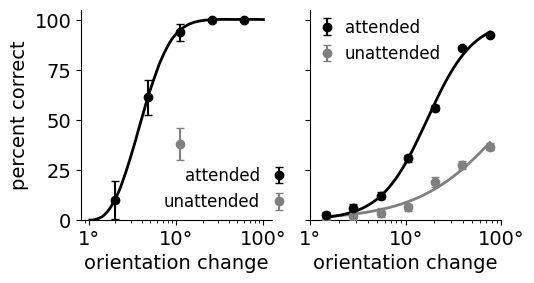

In [12]:
# behavior
df_summary_behavior = df_trials_behavior.groupby(['trial', 'repetition', 'attend_valid', 'change_bin'])['correct'].all().reset_index() # all four time steps need to be correct for the trial to be counted as correct
df_summary_behavior["correct"] = df_summary_behavior["correct"].astype(float) * 100

fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
fig.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.25)

colors = ["gray", "black"] # unattended / attended

# data
df_fig1_c = pd.read_csv("cohen_fig1_c.csv")
attention = extract_web_plot_digitizer_dataset(df_fig1_c, "attention")
axs[0].plot(attention["x"], attention["y"], color=colors[1], linewidth=2)

attention_points_mean = extract_web_plot_digitizer_dataset(df_fig1_c, "attention_points_mean")
attention_points_lower = extract_web_plot_digitizer_dataset(df_fig1_c, "attention_points_lower")
attention_points_upper = extract_web_plot_digitizer_dataset(df_fig1_c, "attention_points_upper")

err_lower = attention_points_mean["y"].values - attention_points_lower["y"].values
err_upper = attention_points_upper["y"].values - attention_points_mean["y"].values

attended_handle = axs[0].errorbar(
    attention_points_mean["x"],
    attention_points_mean["y"],
    yerr=[err_lower, err_upper],
    fmt="o",
    color=colors[1],
    capsize=3,
    label="Attended",
)

unattended = extract_web_plot_digitizer_dataset(df_fig1_c, "unattended")
unattended_lower = extract_web_plot_digitizer_dataset(df_fig1_c, "unattended_lower")
unattended_upper = extract_web_plot_digitizer_dataset(df_fig1_c, "unattended_upper")

err_lower = unattended["y"].values - unattended_lower["y"].values
err_upper = unattended_upper["y"].values - unattended["y"].values

unattended_handle = axs[0].errorbar(
    unattended["x"],
    unattended["y"],
    yerr=[err_lower, err_upper],
    fmt="o",
    color=colors[0],
    capsize=3,
    label="Unattended",
)

# model: error bars + quick sigmoid fit
from scipy.optimize import curve_fit


def sigmoid_logx(x, k, x0):
    z = np.log10(x)
    return 100.0 / (1.0 + np.exp(-k * (z - x0)))


def bootstrap_ci_mean(values, n_boot=1000, ci=95, rng=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if rng is None:
        rng = np.random.default_rng(42)

    boot_means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = sample.mean()

    alpha = (100.0 - ci) / 2.0
    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100.0 - alpha)
    return values.mean(), lower, upper


ax = axs[1]
rng = np.random.default_rng(42)

records = []
for (attend_valid, change_bin), group in df_summary_behavior.groupby(["attend_valid", "change_bin"]):
    mean, ci_low, ci_high = bootstrap_ci_mean(group["correct"].values, n_boot=1000, ci=95, rng=rng)
    records.append(
        {
            "attend_valid": attend_valid,
            "change_bin": change_bin,
            "mean": mean,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )

df_model = pd.DataFrame(records)

for attend_valid, color in zip([False, True], colors):
    df_cond = df_model[df_model["attend_valid"] == attend_valid].sort_values("change_bin")
    x = df_cond["change_bin"].values.astype(float)
    y = df_cond["mean"].values.astype(float)
    yerr_lower = y - df_cond["ci_low"].values.astype(float)
    yerr_upper = df_cond["ci_high"].values.astype(float) - y

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr_lower) & np.isfinite(yerr_upper)
    x = x[valid]
    y = y[valid]
    yerr_lower = yerr_lower[valid]
    yerr_upper = yerr_upper[valid]

    if len(x) == 0:
        continue

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        color=color,
        capsize=3,
        zorder=3,
    )

    if len(x) >= 3 and np.all(x > 0):
        try:
            params, _ = curve_fit(
                sigmoid_logx,
                x,
                y,
                p0=[5.0, 0.8],
                bounds=([0.1, -1.0], [30.0, 3.0]),
                maxfev=10000,
            )
            x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
            y_fit = sigmoid_logx(x_fit, *params)
            ax.plot(x_fit, y_fit, color=color, lw=2)
        except (RuntimeError, ValueError):
            pass

# axs[0].set_title("Data")
# axs[1].set_title("Model")
axs[0].set_ylabel("percent correct")
axs[1].set_ylabel("")
for ax in axs.flatten():
    ax.set_xlabel("orientation change")
    ax.set_ylim(0, 105)
    ax.set_xscale("log")
    ax.set_xticks([1, 10, 100])
    ax.set_xticklabels(["1°", "10°", "100°"])
    ax.spines ["top"].set_visible(False)
    ax.spines ["right"].set_visible(False)

axs[0].legend([attended_handle, unattended_handle], ["attended", "unattended"], 
              handletextpad=0.1,
              title="", loc="lower right", frameon=False, markerfirst=False, bbox_to_anchor=(1.2, -0.03))
right_handles = [
    plt.Line2D([0], [0], color=colors[0], lw=2),
    plt.Line2D([0], [0], color=colors[1], lw=2),
]
axs[1].legend([attended_handle, unattended_handle], ["attended", "unattended"],
              handletextpad=0.1,
                title="", loc="upper left", frameon=False, bbox_to_anchor=(-0.08, 1.03))


fig.savefig(figures_dir / "orientation_change_detection_behavior.pdf", dpi=500, bbox_inches="tight")

In [13]:
# only correct trials ("All analysis used only correctly completed trials")
df_trials = df_trials[df_trials["correct"] == True]

# only consider the time step before the change (according to the paper)
# (also excluding the very first time step since the model doesn't know where to attend yet)
df_trials = df_trials[(df_trials["t"] > 1) & (df_trials["t"] == df_trials["change_t"] - 1)]

In [14]:

trials = df_trials["trial"].values
reps = df_trials["repetition"].values
ts = df_trials["t"].values
energy_cost_cat = pd.Categorical(df_trials["energy_cost"], categories=cfg.experiment.energy_costs)
energy_cost_indices = energy_cost_cat.codes

dfs_to_concat = []
for conv_layer in ["conv3"]: # only interested in conv3 because that's more like v4
    n_channels = 64 if conv_layer == "conv1" else 256
    
    for side in ["left", "right"]:
        activations = activations_np[conv_layer][side][trials, reps, energy_cost_indices, ts, :]

        # Create a dataframe for this layer/side combination
        n_trials = len(df_trials)
        
        # Repeat trial info for each unit
        trial_info_repeated = pd.concat([df_trials] * n_channels, ignore_index=True)
        
        # Create unit and activation columns
        units = np.repeat(range(n_channels), n_trials)
        activations_flat = activations.T.flatten()  # Transpose and flatten
        
        # Add the new columns
        trial_info_repeated['conv_layer'] = conv_layer
        trial_info_repeated['side'] = side
        # trial_info_repeated['pos'] = f'{pos}'
        trial_info_repeated['unit'] = units
        trial_info_repeated['activation'] = activations_flat
        trial_info_repeated['attention'] = trial_info_repeated['attend_left'] if side == 'left' else ~trial_info_repeated['attend_left']
        
        dfs_to_concat.append(trial_info_repeated)

# Combine all layer/side combinations
df = pd.concat(dfs_to_concat, ignore_index=True)
df.sample(20)


,day,orientation_left,orientation_right,attend_left,attend_valid,change_side,change,change_t,target,target_pred,...,t,repetition,trial,correct,change_bin,conv_layer,side,unit,activation,attention
4865847,8,0.955805,1.648571,True,True,0,83.771498,3,1,1,...,2,15,105,True,75.897373,conv3,right,129,0.253873,False
1591699,37,2.220658,2.290244,False,True,1,34.551713,3,1,1,...,2,19,1813,True,39.310852,conv3,left,125,0.000000,False
999347,48,1.642214,1.343160,True,True,0,48.555145,3,1,1,...,2,5,201,True,39.310852,conv3,left,79,0.000000,True
1949525,23,0.979269,1.633842,True,False,1,54.313613,3,1,1,...,2,18,455,True,75.897373,conv3,left,154,0.000000,True
3077720,23,0.979269,1.633842,False,True,1,-62.554007,3,1,1,...,2,5,1083,True,75.897373,conv3,left,243,0.000000,False
5141606,27,1.878358,2.896153,False,True,1,-24.815748,3,1,1,...,2,12,1720,True,20.360956,conv3,right,150,0.000000,True
6134164,36,0.017348,2.561848,False,True,1,-48.369804,3,1,1,...,2,3,889,True,39.310852,conv3,right,229,0.000000,True
253694,30,1.221066,0.852468,True,True,0,-40.068456,3,1,1,...,2,4,140,True,39.310852,conv3,left,20,0.000000,True
1244859,35,2.426079,0.624284,True,False,1,-23.722281,3,1,1,...,2,13,897,True,20.360956,conv3,left,98,0.000000,True
5058680,4,1.888458,2.224476,True,False,1,33.126677,3,1,1,...,2,9,596,True,39.310852,conv3,right,144,0.189099,False


In [15]:
# find 0 activation mean units (undefined fano factor)
df_mean_activation = df.groupby(["conv_layer", "side", "unit"])["activation"].mean().reset_index()
df_mean_activation_zero = df_mean_activation[df_mean_activation["activation"] == 0.0]
print(df_mean_activation_zero)

# filter them out
df = df[~df["unit"].isin(df_mean_activation_zero["unit"])]

    conv_layer   side  unit  activation
1        conv3   left     1         0.0
18       conv3   left    18         0.0
19       conv3   left    19         0.0
33       conv3   left    33         0.0
37       conv3   left    37         0.0
44       conv3   left    44         0.0
63       conv3   left    63         0.0
65       conv3   left    65         0.0
110      conv3   left   110         0.0
143      conv3   left   143         0.0
163      conv3   left   163         0.0
167      conv3   left   167         0.0
172      conv3   left   172         0.0
173      conv3   left   173         0.0
183      conv3   left   183         0.0
209      conv3   left   209         0.0
257      conv3  right     1         0.0
274      conv3  right    18         0.0
275      conv3  right    19         0.0
289      conv3  right    33         0.0
293      conv3  right    37         0.0
295      conv3  right    39         0.0
300      conv3  right    44         0.0
319      conv3  right    63         0.0


In [16]:
# # scaling up activations to a more reasonable firing rate range
df['spike_rate'] = df['activation'] * cfg.experiment.activation_to_spike_rate_scaling + cfg.experiment.spike_rate_baseline

# # sampling counts (poisson)
df['spike_count'] = np.random.poisson(df['spike_rate'])

/tmp/ipykernel_783690/1277310315.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_783690/1277310315.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(["attended", "unattended"], rotation=25, ha="center")


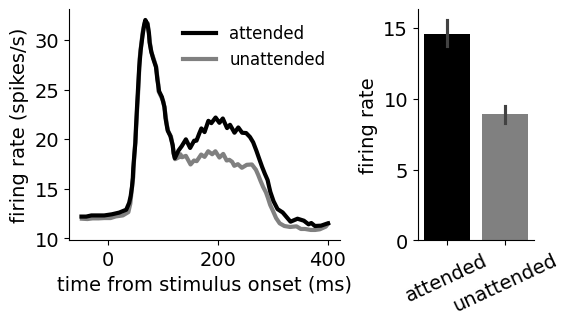

In [17]:
df_sample = df.sample(n=20000)

# increased firing rate
colors = ["black", "gray"] # attended / unattended

fig, axs = plt.subplots(1, 2, figsize=(6, 3), width_ratios=[0.7, 0.3])
fig.subplots_adjust(wspace=0.4)


# data
df_fig2_a = pd.read_csv("cohen_fig2_a.csv")
attended = extract_web_plot_digitizer_dataset(df_fig2_a, "attended")
unattended = extract_web_plot_digitizer_dataset(df_fig2_a, "unattended")
axs[0].plot(attended["x"], attended["y"], linewidth=3, color=colors[0])
axs[0].plot(unattended["x"], unattended["y"], linewidth=3, color=colors[1], zorder=-2)
axs[0].set_xlabel("time from stimulus onset (ms)")
axs[0].set_ylabel("firing rate (spikes/s)")
axs[0].legend(["attended", "unattended"], loc="upper right", frameon=False)


df_sample["not_attention"] = ~df_sample["attention"]

# model
sns.barplot(
    data=df_sample,
    x="not_attention",
    y="spike_count",
    palette=colors,
    ax=axs[1]
)


axs[1].set_xlabel("")
axs[1].set_xticklabels(["attended", "unattended"], rotation=25, ha="center")
axs[1].set_ylabel("firing rate")
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.savefig(figures_dir / "orientation_change_detection_firing_rate.pdf", dpi=500, bbox_inches="tight")


# mean matched fano factor

following cohen & maunsell 2009 (also in churchland et al. 2010)

the idea is to take each time point and attentional condition,
and find a distribution of neurons that has a very similar mean firing rate 



In [18]:
df_spikes = df.groupby(["day", "conv_layer", "side", "unit", "attention"]).agg(
    spike_count_mean=("spike_count", "mean"),
    spike_count_var=("spike_count", "var"),
).reset_index()

df_spikes = df_spikes[df_spikes["spike_count_mean"] <= cfg.experiment.max_rate]

df_spikes["spike_count_var"] /= cfg.experiment.variance_divide_factor
df_spikes["spike_count_var"] += cfg.experiment.spike_rate_baseline


df_spikes

,day,conv_layer,side,unit,attention,spike_count_mean,spike_count_var
0,0,conv3,left,0,False,86.994819,75.782030
2,0,conv3,left,2,False,0.989637,1.042182
3,0,conv3,left,2,True,1.011111,1.040776
4,0,conv3,left,3,False,14.284974,27.649825
5,0,conv3,left,3,True,18.200000,36.065587
...,...,...,...,...,...,...,...
47195,49,conv3,right,253,True,0.987500,1.053790
47196,49,conv3,right,254,False,0.892045,1.044843
47197,49,conv3,right,254,True,0.837500,1.038536
47198,49,conv3,right,255,False,1.068182,1.058052


1.0482553554045018 0.010345986218664971
1.1886748472858548 0.010834852643129006


,attention,ff_slope,ff_intercept,bootstrap_iteration
0,True,1.056644,0.677552,0
1,True,1.043436,0.724236,1
2,True,1.051283,0.702810,2
3,True,1.037421,0.739797,3
4,True,1.045705,0.705336,4
...,...,...,...,...
1995,False,1.169072,0.384524,995
1996,False,1.195091,0.309671,996
1997,False,1.169265,0.365790,997
1998,False,1.157454,0.417015,998


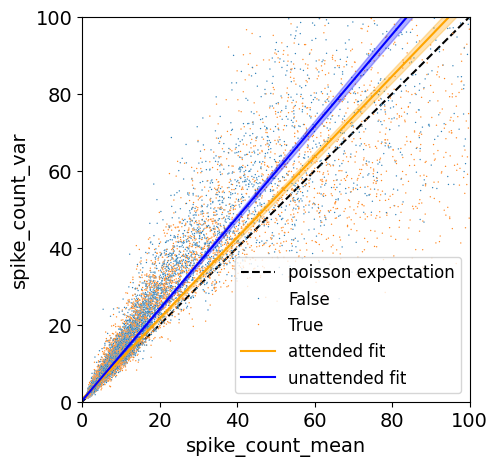

In [19]:
# raw fano factor
# df_spikes["fano_factor"] = df_spikes["spike_count_var"] / df_spikes["spike_count_mean"]
# fig, ax = plt.subplots(1, 1, figsize=(2, 3))
# sns.barplot(df_spikes, x="attention",  y="fano_factor", ax=ax)
# ax.set_ylim(1.0, 1.3)

# fit regression line
from sklearn.linear_model import LinearRegression


def fano_factor_regression(df_target,
                           fit_intercept=True,
                           min_rate=0.005):
    results = {}
    df = df_target[(df_target["spike_count_mean"] >= min_rate)]

    data = {
        "attention" : [],
        "ff_slope" : [],
        "ff_intercept" : [],
        "bootstrap_iteration" : [],
    }

    for attention in [True, False]:
        df_attention = df[(df["attention"] == attention)]
        model = LinearRegression(fit_intercept=fit_intercept)
        mean, var = df_attention["spike_count_mean"].values.reshape(-1, 1), df_attention["spike_count_var"].values.reshape(-1, 1)
        model.fit(mean, var)
        slope = model.coef_[0][0]
        if fit_intercept:
            intercept = model.intercept_[0]
        else:
            intercept = 0

        n_boot = 1000
        slopes = np.zeros(n_boot)
        for i in range(n_boot):
            idx = np.random.choice(len(mean), len(mean), replace=True)
            model_boot = LinearRegression(fit_intercept=fit_intercept)
            model_boot.fit(mean[idx], var[idx])
            slopes[i] = model_boot.coef_[0][0]
            data["attention"].append(attention)
            data["ff_slope"].append(model_boot.coef_[0][0])
            data["ff_intercept"].append(model_boot.intercept_[0] if fit_intercept else 0)
            data["bootstrap_iteration"].append(i)

        print(slopes.mean(), slopes.std())

        ci_lower = np.percentile(slopes, 2.5)
        ci_upper = np.percentile(slopes, 97.5)

        label = "attended" if attention else "unattended"
        results[attention] = {
            "slope": slope,
            "intercept": intercept,
            # "r_value": r_value,
            # "p_value": p_value,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    xlim = cfg.experiment.max_rate
    ylim = cfg.experiment.max_rate
    ax.plot([0, xlim], [0, xlim], color="black", linestyle="--", label="poisson expectation", zorder=-1)
    sns.scatterplot(
        data=df,
        x='spike_count_mean',
        y='spike_count_var',
        hue='attention',
        ax=ax,
        s=1.0,
    )
    ax.set_xlim(0, xlim)
    ax.set_ylim(0, ylim)

    # plot regression lines
    x_vals = np.array([0, xlim])
    for attention, color in zip([True, False], ["orange", "blue"]):
        slope = results[attention]["slope"]
        intercept = results[attention]["intercept"]
        y_vals = intercept + slope * x_vals
        label = "attended" if attention else "unattended"
        ax.plot(x_vals, y_vals, color=color, label=f"{label} fit")
        # plot ci
        ci_lower, ci_upper = results[attention]["ci_lower"], results[attention]["ci_upper"]
        ax.fill_between(x_vals, 
                        ci_lower * x_vals + intercept,
                        ci_upper * x_vals + intercept,
                        color=color, alpha=0.3)

    ax.legend()

    return pd.DataFrame(data)

fano_factor_regression(df_spikes)

In [20]:
def find_common_distribution(df_spikes, n_bins=10):
    """
    Find the common distribution of mean firing rates across day-attention combinations.
    
    Parameters:
    - df_spikes: DataFrame with columns ['day', 'attention', 'spike_count_mean']
    - n_bins: number of bins for histogram
    
    Returns:
    - dict with bin_edges and common_counts
    """
    # Define bin edges based on percentiles of the overall distribution
    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(df_spikes['spike_count_mean'], percentiles)
    print(bin_edges)
    bin_edges = np.unique(bin_edges)  # Remove duplicates if any
    
    # Count units in each bin for each day-attention combination
    all_counts = []
    for (day, attention, side), group in df_spikes.groupby(['day', 'attention', 'side']):
        counts, _ = np.histogram(group['spike_count_mean'], bins=bin_edges)
        all_counts.append(counts)
    # Find minimum count in each bin (the bottleneck)
    common_counts = np.min(all_counts, axis=0)
    
    return {
        'bin_edges': bin_edges,
        'common_counts': common_counts
    }

common_dist = find_common_distribution(df_spikes, 10) 
common_dist

[ 0.47368421  0.91472868  0.96428571  1.          1.04511278  1.09714286
  1.1942446   1.76        4.64615385 15.9375     99.99606299]


{'bin_edges': array([ 0.47368421,  0.91472868,  0.96428571,  1.        ,  1.04511278,
         1.09714286,  1.1942446 ,  1.76      ,  4.64615385, 15.9375    ,
        99.99606299]),
 'common_counts': array([ 4,  7,  0, 13, 10,  8,  9,  6,  9, 16])}

In [21]:
def subsample_for_matching(df_spikes, common_dist):
    """
    Subsample units to match the common distribution.
    
    Parameters:
    - df_spikes: DataFrame with mean firing rates
    - common_dist: output from find_common_distribution
    
    Returns:
    - DataFrame with subsampled units
    """
    bin_edges = common_dist['bin_edges']
    target_counts = common_dist['common_counts']
    
    matched_units = []
    
    for (day, side, attention), group in df_spikes.groupby(['day', 'side', 'attention']):
        # Assign each unit to a bin
        group = group.copy()
        group['bin'] = pd.cut(group['spike_count_mean'], bins=bin_edges, 
                             include_lowest=True, labels=False)
        
        # Sample from each bin
        for bin_idx, target_count in enumerate(target_counts):
            if target_count > 0:  # Only sample if target > 0
                bin_units = group[group['bin'] == bin_idx]
                if len(bin_units) >= target_count:
                    sampled = bin_units.sample(n=int(target_count), random_state=42)
                    matched_units.append(sampled)
                elif len(bin_units) > 0:
                    print(f"Warning: Day {day}, Side {side}, Attention {attention}, Bin {bin_idx}: "
                            f"only {len(bin_units)} units available, need {target_count}")
    
    return pd.concat(matched_units, ignore_index=True) if matched_units else pd.DataFrame()

df_matched = subsample_for_matching(df_spikes, common_dist)
df_matched

,day,conv_layer,side,unit,attention,spike_count_mean,spike_count_var,bin
0,0,conv3,left,169,False,0.844560,1.041494,0
1,0,conv3,left,196,False,0.854922,1.037484,0
2,0,conv3,left,51,False,0.901554,1.041440,0
3,0,conv3,left,188,False,0.849741,1.041834,0
4,0,conv3,left,98,False,0.922280,1.086936,1
...,...,...,...,...,...,...,...,...
16135,49,conv3,right,122,True,17.387500,23.909486,9
16136,49,conv3,right,51,True,96.587500,68.551511,9
16137,49,conv3,right,96,True,91.900000,86.994430,9
16138,49,conv3,right,89,True,38.112500,38.070878,9


1.0476811286480496 0.013710485893616937
1.1875232796135842 0.012364741606734569


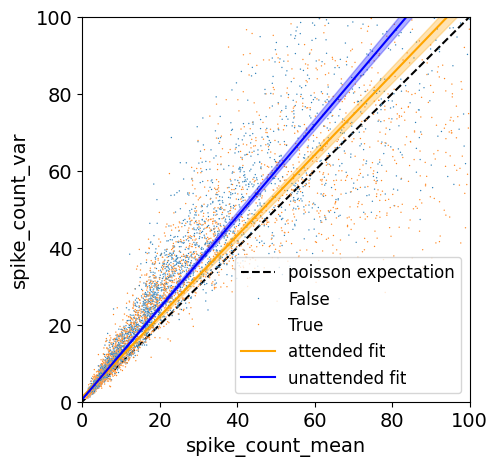

In [22]:

df_mean_matched_ff = fano_factor_regression(df_matched)

/tmp/ipykernel_783690/369572744.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_783690/369572744.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(["attended", "unattended"], rotation=25, ha="center")


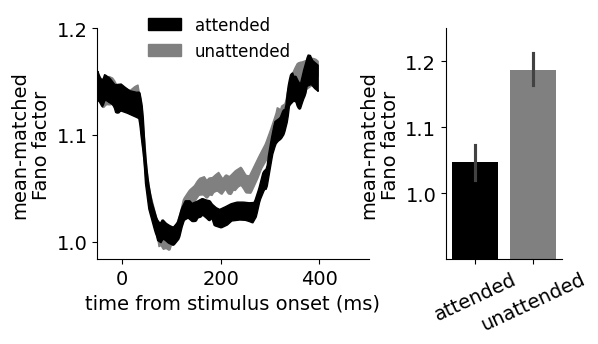

In [23]:
from scipy.interpolate import interp1d

fig, axs = plt.subplots(1, 2, figsize=(6, 3), width_ratios=[0.7, 0.3])
fig.subplots_adjust(wspace=0.4)

colors = ["black", "gray"] # attended / unattended

# data
df_fig2_b = pd.read_csv("cohen_fig2_b.csv")

attended_lower = extract_web_plot_digitizer_dataset(df_fig2_b, "attended_lower")
attended_upper = extract_web_plot_digitizer_dataset(df_fig2_b, "attended_upper")

unattended_lower = extract_web_plot_digitizer_dataset(df_fig2_b, "unattended_lower")
unattended_upper = extract_web_plot_digitizer_dataset(df_fig2_b, "unattended_upper")

# attended
x_common = np.linspace(
    max(attended_lower["x"].min(), attended_upper["x"].min()),
    min(attended_lower["x"].max(), attended_upper["x"].max()),
    200
)
lower_interp = interp1d(attended_lower["x"], attended_lower["y"], kind="linear")
upper_interp = interp1d(attended_upper["x"], attended_upper["y"], kind="linear")
axs[0].fill_between(x_common, lower_interp(x_common), upper_interp(x_common),
                    color=colors[0], alpha=1.0, label="attended")

# unattended
x_common = np.linspace(
    max(unattended_lower["x"].min(), unattended_upper["x"].min()),
    min(unattended_lower["x"].max(), unattended_upper["x"].max()),
    200
)
lower_interp = interp1d(unattended_lower["x"], unattended_lower["y"], kind="linear")
upper_interp = interp1d(unattended_upper["x"], unattended_upper["y"], kind="linear")
axs[0].fill_between(x_common, lower_interp(x_common), upper_interp(x_common),
                    color=colors[1], alpha=1.0, label="Unattended", zorder=-2)


axs[0].set_yticks([1.0, 1.1, 1.2])
axs[0].set_xlim(-50, 500)
axs[0].set_xlabel("time from stimulus onset (ms)")
axs[0].set_ylabel("mean-matched\nFano factor")
axs[0].legend(["attended", "unattended"], loc="upper center", frameon=False, bbox_to_anchor=(0.45, 1.12))


# model
df_mean_matched_ff["not_attention"] = ~df_mean_matched_ff["attention"]

# increased firing rate
sns.barplot(
    data=df_mean_matched_ff,
    x="not_attention",
    y="ff_slope",
    palette=colors,
    errorbar=("pi", 95),
    ax=axs[1]
)

axs[1].set_ylim(0.9, 1.25)

axs[1].set_xlabel("")
axs[1].set_xticklabels(["attended", "unattended"], rotation=25, ha="center")
axs[1].set_ylabel("mean-matched\nFano factor")
axs[1].set_yticks([1.0, 1.1, 1.2])
for ax in axs.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.savefig(figures_dir / "orientation_change_detection_fano_factor.pdf", dpi=500, bbox_inches="tight")


# noise correlation




In [24]:
df["trial"].head()
df["repetition"].head()

0    0
1    0
2    0
3    0
4    0
Name: repetition, dtype: int64

In [25]:

import tqdm

sel = df["conv_layer"] == "conv3"
df_sel = df[sel]

# print("excluding units with low firing rates...")
# unit_means = df_sel.groupby('unit')['spike_count'].mean()
# print("number of units before filtering:", len(unit_means))
# valid_units = unit_means[unit_means >= 0.1].index

# # Filter to only include valid units
# df_sel = df_sel[df_sel['unit'].isin(valid_units)]
# print(f"Number of units after filtering: {len(valid_units)}")

conditions = ["day", "attention", "side"]

noise_corr_dfs = []
for condition_vals, group in tqdm.tqdm(df_sel.groupby(conditions)):
    # print(condition_vals)
    spike_matrix = group.pivot_table(
        index=["trial", "repetition"],
        columns="unit",
        values="spike_count"
    )
    # print(spike_matrix)
    
    # Convert to numpy array
    X = spike_matrix.values  # (n_trials, n_units)
    mean_spike_counts = X.mean(axis=0)
    # print("Mean spike counts:", mean_spike_counts)
    
    # Compute correlation with numpy (faster than pandas)
    corr_matrix = np.corrcoef(X.T)  # Transpose so units are rows
    
    # Vectorized extraction of upper triangle
    n_units = len(spike_matrix.columns)
    i_idx, j_idx = np.triu_indices(n_units, k=1)  # Upper triangle indices
    
    # Pre-create condition dictionary once
    condition_dict = {k: v for k, v in zip(conditions, condition_vals)}
    n_trials = X.shape[0]
    n_pairs = len(i_idx)
    
    # Build DataFrame for this group all at once
    noise_corr_dfs.append(pd.DataFrame({
        **{k: [v] * n_pairs for k, v in condition_dict.items()},
        'unit_i': spike_matrix.columns[i_idx],
        'unit_j': spike_matrix.columns[j_idx],
        'noise_correlation': corr_matrix[i_idx, j_idx],
        'spike_count_mean_i': mean_spike_counts[i_idx],
        'spike_count_mean_j': mean_spike_counts[j_idx],
        'spike_count_mean_pair': (mean_spike_counts[i_idx] + mean_spike_counts[j_idx]) / 2,
        'n_trials': n_trials
    }))

# Concatenate all DataFrames at once
df_noise_corr = pd.concat(noise_corr_dfs, ignore_index=True)
df_noise_corr

100%|██████████| 200/200 [00:08<00:00, 24.73it/s]


,day,attention,side,unit_i,unit_j,noise_correlation,spike_count_mean_i,spike_count_mean_j,spike_count_mean_pair,n_trials
0,0,False,left,0,2,0.065393,86.994819,0.989637,43.992228,193
1,0,False,left,0,3,0.155270,86.994819,14.284974,50.639896,193
2,0,False,left,0,4,-0.021115,86.994819,1.829016,44.411917,193
3,0,False,left,0,5,0.222764,86.994819,20.870466,53.932642,193
4,0,False,left,0,6,0.027293,86.994819,2.041451,44.518135,193
...,...,...,...,...,...,...,...,...,...,...
5545995,49,True,right,252,254,-0.176871,1.187500,0.837500,1.012500,80
5545996,49,True,right,252,255,-0.054861,1.187500,1.100000,1.143750,80
5545997,49,True,right,253,254,0.136755,0.987500,0.837500,0.912500,80
5545998,49,True,right,253,255,-0.017223,0.987500,1.100000,1.043750,80


In [26]:
# bin the spike count mean
df_noise_corr['spike_count_bin'] = pd.cut(
    df_noise_corr['spike_count_mean_pair'],
    bins=np.linspace(0, 20, 21),  # 20 bins from 0 to 20
    include_lowest=True,
    labels=False
)
df_noise_corr

,day,attention,side,unit_i,unit_j,noise_correlation,spike_count_mean_i,spike_count_mean_j,spike_count_mean_pair,n_trials,spike_count_bin
0,0,False,left,0,2,0.065393,86.994819,0.989637,43.992228,193,NaN
1,0,False,left,0,3,0.155270,86.994819,14.284974,50.639896,193,NaN
2,0,False,left,0,4,-0.021115,86.994819,1.829016,44.411917,193,NaN
3,0,False,left,0,5,0.222764,86.994819,20.870466,53.932642,193,NaN
4,0,False,left,0,6,0.027293,86.994819,2.041451,44.518135,193,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5545995,49,True,right,252,254,-0.176871,1.187500,0.837500,1.012500,80,1.0
5545996,49,True,right,252,255,-0.054861,1.187500,1.100000,1.143750,80,1.0
5545997,49,True,right,253,254,0.136755,0.987500,0.837500,0.912500,80,0.0
5545998,49,True,right,253,255,-0.017223,0.987500,1.100000,1.043750,80,1.0


In [27]:
import numpy as np
import pandas as pd

sel = df["conv_layer"] == "conv3"
df_sel = df[sel]

results = []


for day in df_sel['day'].unique():
    day_group = df_sel[df_sel['day'] == day]
    
    # Group by which side was attended (attend_left=True or False)
    for attend_left_val in [True, False]:
        # Get all data for trials where this side was attended
        trial_group = day_group[day_group['attend_left'] == attend_left_val]
        
        # Pivot to get spike matrix: rows=trials, columns=(side, unit)
        spike_matrix = trial_group.pivot_table(
            index=["trial", "repetition"],
            columns=["side", "unit"],
            values="spike_count"
        )
        
        spike_means = spike_matrix.mean(axis=0)

        # Separate left and right units
        left_mask = spike_matrix.columns.get_level_values('side') == 'left'
        right_mask = spike_matrix.columns.get_level_values('side') == 'right'
        
        X_left = spike_matrix.loc[:, left_mask].values
        X_right = spike_matrix.loc[:, right_mask].values

        X_combined = np.column_stack([X_left, X_right])
        corr_combined = np.corrcoef(X_combined.T)

        n_left = X_left.shape[1]
        n_right = X_right.shape[1]

        # Extract the three regions
        corr_left = corr_combined[:n_left, :n_left]
        corr_right = corr_combined[n_left:, n_left:]
        corr_left_to_right = corr_combined[:n_left, n_left:]

        # Extract unit IDs
        left_units = [col[1] for col in spike_matrix.columns if col[0] == 'left']
        right_units = [col[1] for col in spike_matrix.columns if col[0] == 'right']

        # Process both hemispheres in one loop
        for side, units, start_idx in [('left', left_units, 0), 
                                        ('right', right_units, n_left)]:
            for i, unit_id in enumerate(units):
                global_idx = start_idx + i
                
                # Within-hemisphere correlations (exclude self)
                within_start = start_idx
                within_end = start_idx + len(units)
                within_corrs = np.concatenate([
                    corr_combined[global_idx, within_start:global_idx],
                    corr_combined[global_idx, global_idx+1:within_end]
                ])
                
                # Across-hemisphere correlations
                if side == 'left':
                    across_corrs = corr_combined[global_idx, n_left:]
                    attended = attend_left_val
                else:
                    across_corrs = corr_combined[global_idx, :n_left]
                    attended = not attend_left_val

                for within in [False, True]:
                    corr = across_corrs if not within else within_corrs
                    results.append({
                        "day": day,
                        "side": side,
                        "unit": unit_id,
                        "spike_mean": spike_means[(side, unit_id)],
                        "attend_left": attend_left_val,
                        "within": within,
                        "attended": attended,
                        "noise_correlation": np.nanmean(corr),
                    })

df_unit_corr = pd.DataFrame(results)
df_unit_corr

,day,side,unit,spike_mean,attend_left,within,attended,noise_correlation
0,40,left,0,0.966667,True,False,True,-0.002849
1,40,left,0,0.966667,True,True,True,0.000545
2,40,left,2,0.941667,True,False,True,-0.001299
3,40,left,2,0.941667,True,True,True,0.004883
4,40,left,3,1.016667,True,False,True,0.000135
...,...,...,...,...,...,...,...,...
94395,35,right,253,0.866667,False,True,True,0.014144
94396,35,right,254,3.466667,False,False,True,-0.005704
94397,35,right,254,3.466667,False,True,True,-0.003608
94398,35,right,255,0.833333,False,False,True,-0.002887


In [28]:

spike_mean_bins = np.linspace(cfg.experiment.spike_rate_baseline, cfg.experiment.max_rate_noise_correlation_to_plot, 11)
spike_mean_bin_labels = [f"{(spike_mean_bins[i]+spike_mean_bins[i+1])/2:.0f}" for i in range(len(spike_mean_bins)-1)]

# bin the spike count mean
df_unit_corr['spike_mean_bin'] = pd.cut(
    df_unit_corr['spike_mean'],
    bins=spike_mean_bins,
    include_lowest=True,
    labels=False,
)
df_unit_corr

,day,side,unit,spike_mean,attend_left,within,attended,noise_correlation,spike_mean_bin
0,40,left,0,0.966667,True,False,True,-0.002849,NaN
1,40,left,0,0.966667,True,True,True,0.000545,NaN
2,40,left,2,0.941667,True,False,True,-0.001299,NaN
3,40,left,2,0.941667,True,True,True,0.004883,NaN
4,40,left,3,1.016667,True,False,True,0.000135,0.0
...,...,...,...,...,...,...,...,...,...
94395,35,right,253,0.866667,False,True,True,0.014144,NaN
94396,35,right,254,3.466667,False,False,True,-0.005704,0.0
94397,35,right,254,3.466667,False,True,True,-0.003608,0.0
94398,35,right,255,0.833333,False,False,True,-0.002887,NaN


In [29]:

def get_unit_condition(row):
    if row['within']:
        if row['attended']:
            return 'Attended'
        else:
            return 'Unattended'
    else:
        return 'Opposite hemispheres'

df_unit_corr["unit_condition"] = df_unit_corr.apply(get_unit_condition, axis=1)
df_unit_corr

,day,side,unit,spike_mean,attend_left,within,attended,noise_correlation,spike_mean_bin,unit_condition
0,40,left,0,0.966667,True,False,True,-0.002849,NaN,Opposite hemispheres
1,40,left,0,0.966667,True,True,True,0.000545,NaN,Attended
2,40,left,2,0.941667,True,False,True,-0.001299,NaN,Opposite hemispheres
3,40,left,2,0.941667,True,True,True,0.004883,NaN,Attended
4,40,left,3,1.016667,True,False,True,0.000135,0.0,Opposite hemispheres
...,...,...,...,...,...,...,...,...,...,...
94395,35,right,253,0.866667,False,True,True,0.014144,NaN,Attended
94396,35,right,254,3.466667,False,False,True,-0.005704,0.0,Opposite hemispheres
94397,35,right,254,3.466667,False,True,True,-0.003608,0.0,Attended
94398,35,right,255,0.833333,False,False,True,-0.002887,NaN,Opposite hemispheres


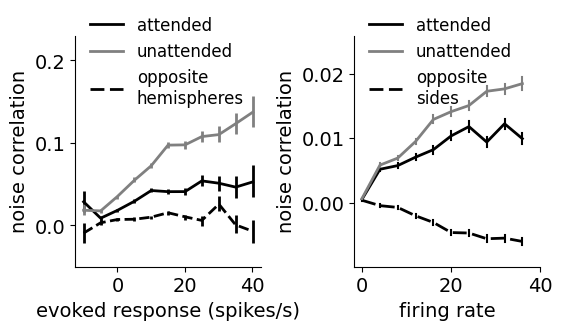

In [30]:
colors = {
    "Attended": "black",
    "Unattended": "gray",
    "Opposite hemispheres": "black"
}

dashes = {
    "Attended": "",  # solid line
    "Unattended": "",  # solid line
    "Opposite hemispheres": (5, 2)  # dashed line
}

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
fig.subplots_adjust(wspace=0.5)


# data
df_fig2_c = pd.read_csv("cohen_fig2_c.csv")
data = {}
for condition in ["attended", "unattended", "opposite"]:
    for y in ["lower", "mean", "upper"]:
        col_name = f"{condition}_{y}"
        data[col_name] = extract_web_plot_digitizer_dataset(df_fig2_c, col_name)

axs[0].errorbar(
    data["attended_mean"]["x"],
    data["attended_mean"]["y"],
    yerr=[data["attended_mean"]["y"] - data["attended_lower"]["y"],
            data["attended_upper"]["y"] - data["attended_mean"]["y"]],
    color=colors["Attended"],
    capsize=0,
    label="attended",
    linewidth=2,
)

axs[0].errorbar(
    data["attended_mean"]["x"],
    data["unattended_mean"]["y"],
    yerr=[data["unattended_mean"]["y"] - data["unattended_lower"]["y"],
            data["unattended_upper"]["y"] - data["unattended_mean"]["y"]],
    color=colors["Unattended"],
    capsize=0,
    label="unattended",
    linewidth=2,
)

axs[0].errorbar(
    data["attended_mean"]["x"],
    data["opposite_mean"]["y"],
    yerr=[data["opposite_mean"]["y"] - data["opposite_lower"]["y"],
            data["opposite_upper"]["y"] - data["opposite_mean"]["y"]],
    color=colors["Opposite hemispheres"],
    linestyle="dashed",
    capsize=0,
    label="opposite hemispheres",
    linewidth=2,
)

axs[0].set_ylim(-0.05, 0.23)
axs[0].set_yticks([0.0, 0.1, 0.2])
axs[0].set_xlabel("evoked response (spikes/s)")
axs[0].set_ylabel("noise correlation")

# model
sns.lineplot(df_unit_corr, x="spike_mean_bin",
                y="noise_correlation", hue="unit_condition",
                palette=colors, style="unit_condition",
                dashes=dashes, errorbar="se",
                err_style="bars",
                ax=axs[1], lw=2)
axs[1].set_xlabel("firing rate")
axs[1].set_ylabel("noise correlation")
axs[1].set_ylim(-0.01, 0.026)
axs[1].set_xticks([0, 5, 10])
axs[1].set_xticklabels(["0", "20", "40"])

axs[1].set_yticks(np.arange(-0.00, 0.026, 0.01))


handles, labels = axs[1].get_legend_handles_labels()
labels = ["opposite\nhemispheres", "attended", "unattended"]
order = [1, 2, 0]
axs[0].legend([handles[i] for i in order], [labels[i] for i in order], title="", loc="upper left", frameon=False, bbox_to_anchor=(0, 1.15))

labels = ["opposite\nsides", "attended", "unattended"]
order = [1, 2, 0]
axs[1].legend([handles[i] for i in order], [labels[i] for i in order], title="", loc="upper left", frameon=False, bbox_to_anchor=(0, 1.15))
# remove legend
# axs[1].legend_.remove()

for ax in axs.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.savefig(figures_dir / "orientation_change_detection_noise_correlation.pdf", dpi=500, bbox_inches="tight")
